# Nome: Davi S. Mattos
## DRE: 119133049

# Algoritmo Evolutivo

In [157]:
import numpy as np
from random import random, seed

#np.random.seed(42)

def rosenbrock(X):
  """
  Função de Rosenbrock

  X -> Vetor de entrada

  """
  X = np.array(X)
  if X.ndim > 1:
    return np.sum(100 * (X[:, 1:] - X[:, :-1]**2)**2 + (X[:, :-1] - 1)**2, axis=1)
  else:
    return np.sum(100 * (X[1:] - X[:-1]**2)**2 + (X[:-1] - 1)**2, axis=0)

In [158]:
def criar_populacao(dimensao, num_individuos, intervalo):
  """
  Função que cria uma população com N indivíduos.

  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão

  """

  populacao = []
  for i in range(num_individuos):
    individuo = []
    for j in range(dimensao):
      individuo.append(np.random.uniform(intervalo[0], intervalo[1]))
    populacao.append(individuo)

  return np.array(populacao)

In [159]:
def melhor_individuo(populacao, funcao_avaliacao):
  fitness = funcao_avaliacao(populacao)
  melhor_individuo = populacao[np.argmin(fitness)]
  return melhor_individuo

In [160]:
def rand_1(populacao, i, F=0.9, problema=None):
    n = len(populacao)

    indices = list(range(n))
    indices.remove(i)

    r0, r1, r2 = np.random.choice(indices, 3, replace=False)

    return populacao[r0] + F * (populacao[r1] - populacao[r2])

In [161]:
def cruzamento(individuo, vetor_mutante, CR= 0.9):

  individuo_cruzado = []
  for i in range(len(individuo)):
    if np.random.random() < CR:
      individuo_cruzado.append(vetor_mutante[i])
    else:
      individuo_cruzado.append(individuo[i])

  return individuo_cruzado

In [162]:
def algoritmo_evolutivo(problema=rosenbrock, dimensao=2, n_individuos=100, intervalo=[-5,10], estrategia= rand_1, f=0.9, cr= 0.9, parada=100000, history=None, printf=False):
    populacao = criar_populacao(dimensao, n_individuos, intervalo)

    fitness = problema(populacao)
    historico = [np.min(fitness)]

    chamada_funcao = n_individuos
    while (chamada_funcao < parada):

      for i in range(len(populacao)):
        if chamada_funcao >= parada:
            break

        individuo = populacao[i].copy()

        vetor_mutante = estrategia(populacao, i, f, fitness)

        teste = cruzamento(individuo, vetor_mutante, cr)

        fx = problema(teste)
        if fx < fitness[i]:
            populacao[i] = teste
            fitness[i] = fx
        chamada_funcao += 1
        historico.append(np.min(fitness).copy())


    best = melhor_individuo(populacao, problema)
    if printf:
      print(f"Melhor individuo: {best}\nF(x*)= {problema(best)}\niterações: {chamada_funcao}")
    if history == None:
      return problema(best)
    else:
      return best, historico


In [163]:
_ = algoritmo_evolutivo(dimensao=2, parada=10000, printf=True)

Melhor individuo: [1.00009737 1.00019217]
F(x*)= 1.014570301546619e-08
iterações: 10000


## Gráfico de Convergência Média

In [164]:
n_exec = 30
max_fes = 10000

historico_rand1 = []

for i in range(n_exec):
  np.random.seed(i)
  _, hist = algoritmo_evolutivo(dimensao=2, parada=max_fes, history=True)
  historico_rand1.append(hist)
  if (i+1) % 10 == 0:
    print(f"{i+1}/{n_exec}")

min_len = min(len(h) for h in historico_rand1)
historico_rand1 = np.array([h[:min_len] for h in historico_rand1])


media_rand1 = np.mean(historico_rand1, axis=0)
desvio_rand1 = np.std(historico_rand1, axis=0)

eixo = np.arange(min_len)

10/30
20/30
30/30


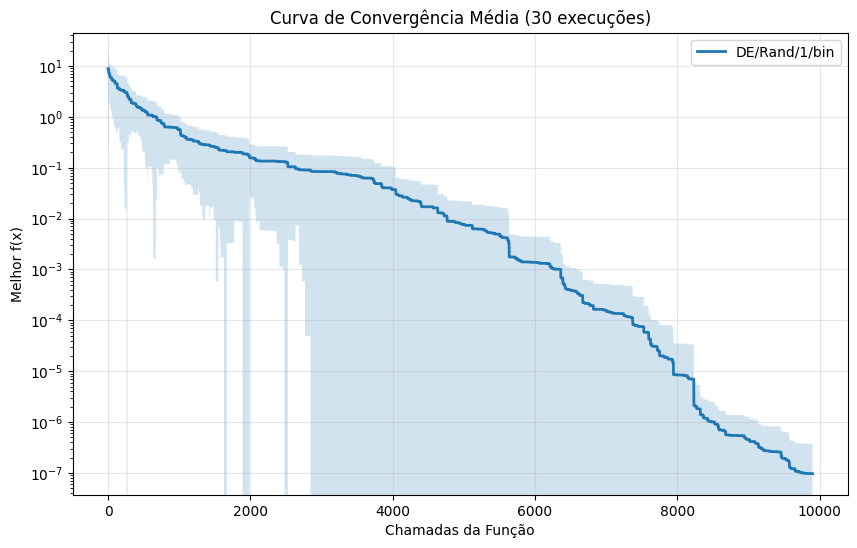

In [165]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))

# Adjust eixo to match the length of media and desvio
plt.plot(range(min_len), media_rand1, label="DE/Rand/1/bin", linewidth=2)

plt.fill_between(
    range(min_len),
    media_rand1 - desvio_rand1,
    media_rand1 + desvio_rand1,
    alpha=0.2,
)

plt.yscale("log")
plt.xlabel("Chamadas da Função")
plt.ylabel("Melhor f(x)")
plt.title("Curva de Convergência Média (30 execuções)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Mutações

In [166]:
def rand_2(populacao, i, F, fitness):
    idxs = list(range(len(populacao)))
    idxs.remove(i)

    r1, r2, r3, r4, r5 = np.random.choice(idxs, 5, replace=False)

    return (
        populacao[r1]
        + F * (populacao[r2] - populacao[r3])
        + F * (populacao[r4] - populacao[r5])
    )

In [167]:
def best_1(pop, i, F, fitness):
    best_idx = np.argmin(fitness)
    best = pop[best_idx]

    idxs = list(range(len(pop)))
    idxs.remove(i)  # evita usar o próprio indivíduo

    r1, r2 = np.random.choice(idxs, 2, replace=False)

    return best + F * (pop[r1] - pop[r2])

In [168]:
def best_2(pop, i, F, fitness):
    best_idx = np.argmin(fitness)
    best = pop[best_idx]

    idxs = list(range(len(pop)))
    idxs.remove(i)  # evita usar o próprio indivíduo
    r1, r2, r3, r4 = np.random.choice(idxs, 4, replace=False)

    return (
        best
        + F * (pop[r1] - pop[r2])
        + F * (pop[r3] - pop[r4])
    )

In [169]:
def current_to_best_1(pop, i, F, fitness):
    best_idx = np.argmin(fitness)
    best = pop[best_idx]

    idxs = list(range(len(pop)))
    idxs.remove(i)  # evita usar o próprio indivíduo

    r1, r2 = np.random.choice(idxs, 2, replace=False)

    x = pop[i]

    return x + F * (best - x) + F * (pop[r1] - pop[r2])

In [170]:
algoritmo_evolutivo(estrategia=rand_2, parada=10000, printf=True)

Melhor individuo: [1.12559318 1.25055409]
F(x*)= 0.042689057810817055
iterações: 10000


np.float64(0.042689057810817055)

In [171]:
algoritmo_evolutivo(estrategia=best_1, parada=10000, printf=True)

Melhor individuo: [1. 1.]
F(x*)= 3.768035140739904e-19
iterações: 10000


np.float64(3.768035140739904e-19)

In [172]:
algoritmo_evolutivo(estrategia=best_2, parada=10000, printf=True)

Melhor individuo: [0.96153128 0.92379074]
F(x*)= 0.0015363429742731379
iterações: 10000


np.float64(0.0015363429742731379)

In [173]:
algoritmo_evolutivo(estrategia=current_to_best_1, parada=10000, printf=True)

Melhor individuo: [1. 1.]
F(x*)= 1.4760789046847198e-18
iterações: 10000


np.float64(1.4760789046847198e-18)

In [174]:
n_exec = 30
max_fes = 10000
n_individuos = 100

historico_rand1 = []
historico_rand2 = []
historico_best1 = []
historico_best2 = []
historico_current_to_best_1 = []

for i in range(n_exec):
  np.random.seed(i)

  # Rand/1
  _, hist1 = algoritmo_evolutivo(dimensao=2, estrategia=rand_1, parada=max_fes, history=True)
  historico_rand1.append(hist1)

  # Rand/2
  _, hist2 = algoritmo_evolutivo(dimensao=2, estrategia=rand_2, parada=max_fes, history=True)
  historico_rand2.append(hist2)

  # Best/1
  _, hist3 = algoritmo_evolutivo(dimensao=2, estrategia=best_1, parada=max_fes, history=True)
  historico_best1.append(hist3)

  # Best/2
  _, hist4 = algoritmo_evolutivo(dimensao=2, estrategia=best_2, parada=max_fes, history=True)
  historico_best2.append(hist4)

  # Current to Best/1
  _, hist5 = algoritmo_evolutivo(dimensao=2, estrategia=current_to_best_1, parada=max_fes, history=True)
  historico_current_to_best_1.append(hist5)


  if (i+1) % 10 == 0:
    print(f"{i+1}/{n_exec}")

# Rand/1
min_len1 = min(len(h) for h in historico_rand1)
historico_rand1 = np.array([h[:min_len1] for h in historico_rand1])

# Rand/2
min_len2 = min(len(h) for h in historico_rand2)
historico_rand2 = np.array([h[:min_len2] for h in historico_rand2])

# Best/1
min_len3 = min(len(h) for h in historico_best1)
historico_best1 = np.array([h[:min_len3] for h in historico_best1])

# Best/2
min_len4 = min(len(h) for h in historico_best2)
historico_best2 = np.array([h[:min_len4] for h in historico_best2])

# Current to Best/1
min_len5 = min(len(h) for h in historico_current_to_best_1)
historico_current_to_best_1 = np.array([h[:min_len5] for h in historico_current_to_best_1])


# Rand/1
media_rand1 = np.mean(historico_rand1, axis=0)
desvio_rand1 = np.std(historico_rand1, axis=0)

# Rand/2
media_rand2 = np.mean(historico_rand2, axis=0)
desvio_rand2 = np.std(historico_rand2, axis=0)

# Best/1
media_best1 = np.mean(historico_best1, axis=0)
desvio_best1 = np.std(historico_best1, axis=0)

# Best/2
media_best2 = np.mean(historico_best2, axis=0)
desvio_best2 = np.std(historico_best2, axis=0)

# Current to Best/1
media_current_to_best_1 = np.mean(historico_current_to_best_1, axis=0)
desvio_current_to_best_1 = np.std(historico_current_to_best_1, axis=0)

min_len_global = min(
    min_len1, min_len2, min_len3, min_len4, min_len5
)

10/30
20/30
30/30


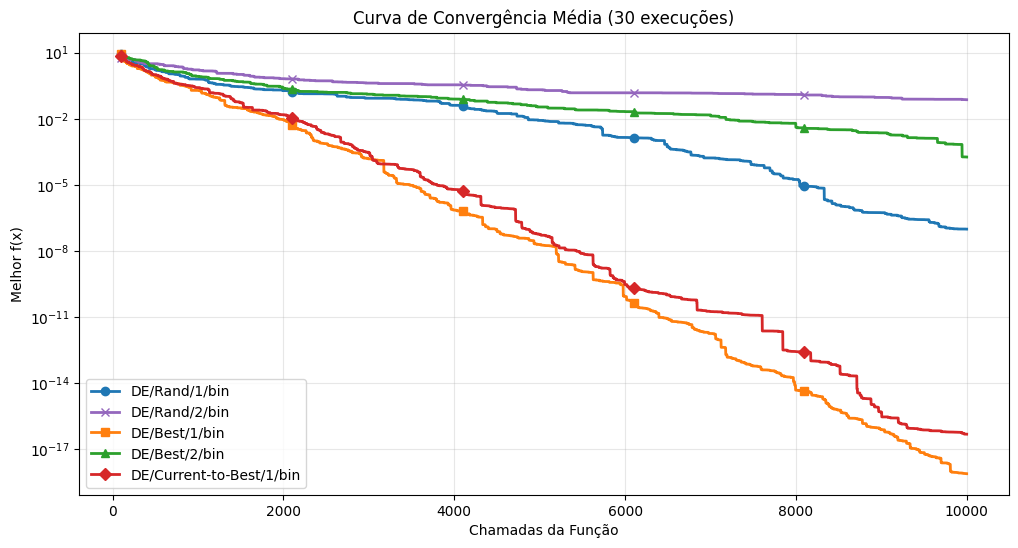

In [175]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))

eixo = np.arange(100, 100 + min_len_global)  # ← começa em 100

cores = ['#1f77b4', '#9467bd', '#ff7f0e', '#2ca02c', '#d62728']
marcadores = ['o', 'x', 's', '^', 'D']

plt.plot(eixo, media_rand1, label="DE/Rand/1/bin", color = cores[0], marker=marcadores[0], markersize=6, markevery=2000, linewidth=2)
plt.plot(eixo, media_rand2, label="DE/Rand/2/bin", color = cores[1], marker=marcadores[1], markersize=6, markevery=2000, linewidth=2)
plt.plot(eixo, media_best1, label="DE/Best/1/bin", color = cores[2], marker=marcadores[2], markersize=6, markevery=2000, linewidth=2)
plt.plot(eixo, media_best2, label="DE/Best/2/bin", color = cores[3], marker=marcadores[3], markersize=6, markevery=2000, linewidth=2)
plt.plot(eixo, media_current_to_best_1, label="DE/Current-to-Best/1/bin", color = cores[4], marker=marcadores[4], markersize=6, markevery=2000, linewidth=2)

#plt.fill_between(
#    range(min_len1),
#    media_rand1 - desvio_rand1,
#    media_rand1 + desvio_rand1,
#    alpha=0.1,
#)

#plt.fill_between(
#    range(min_len2),
#    media_rand2 - desvio_rand2,
#    media_rand2 + desvio_rand2,
#    alpha=0.1,
#)

#plt.fill_between(
#    range(min_len3),
#    media_best1 - desvio_best1,
#    media_best1 + desvio_best1,
#    alpha=0.1,
#)

#plt.fill_between(
#    range(min_len4),
#    media_best2 - desvio_best2,
#    media_best2 + desvio_best2,
#    alpha=0.1,
#)

#plt.fill_between(
#    range(min_len5),
#    media_current_to_best_1 - desvio_current_to_best_1,
#    media_current_to_best_1 + desvio_current_to_best_1,
#    alpha=0.1,
#)

plt.yscale("log")
plt.xlabel("Chamadas da Função")
plt.ylabel("Melhor f(x)")
plt.title("Curva de Convergência Média (30 execuções)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

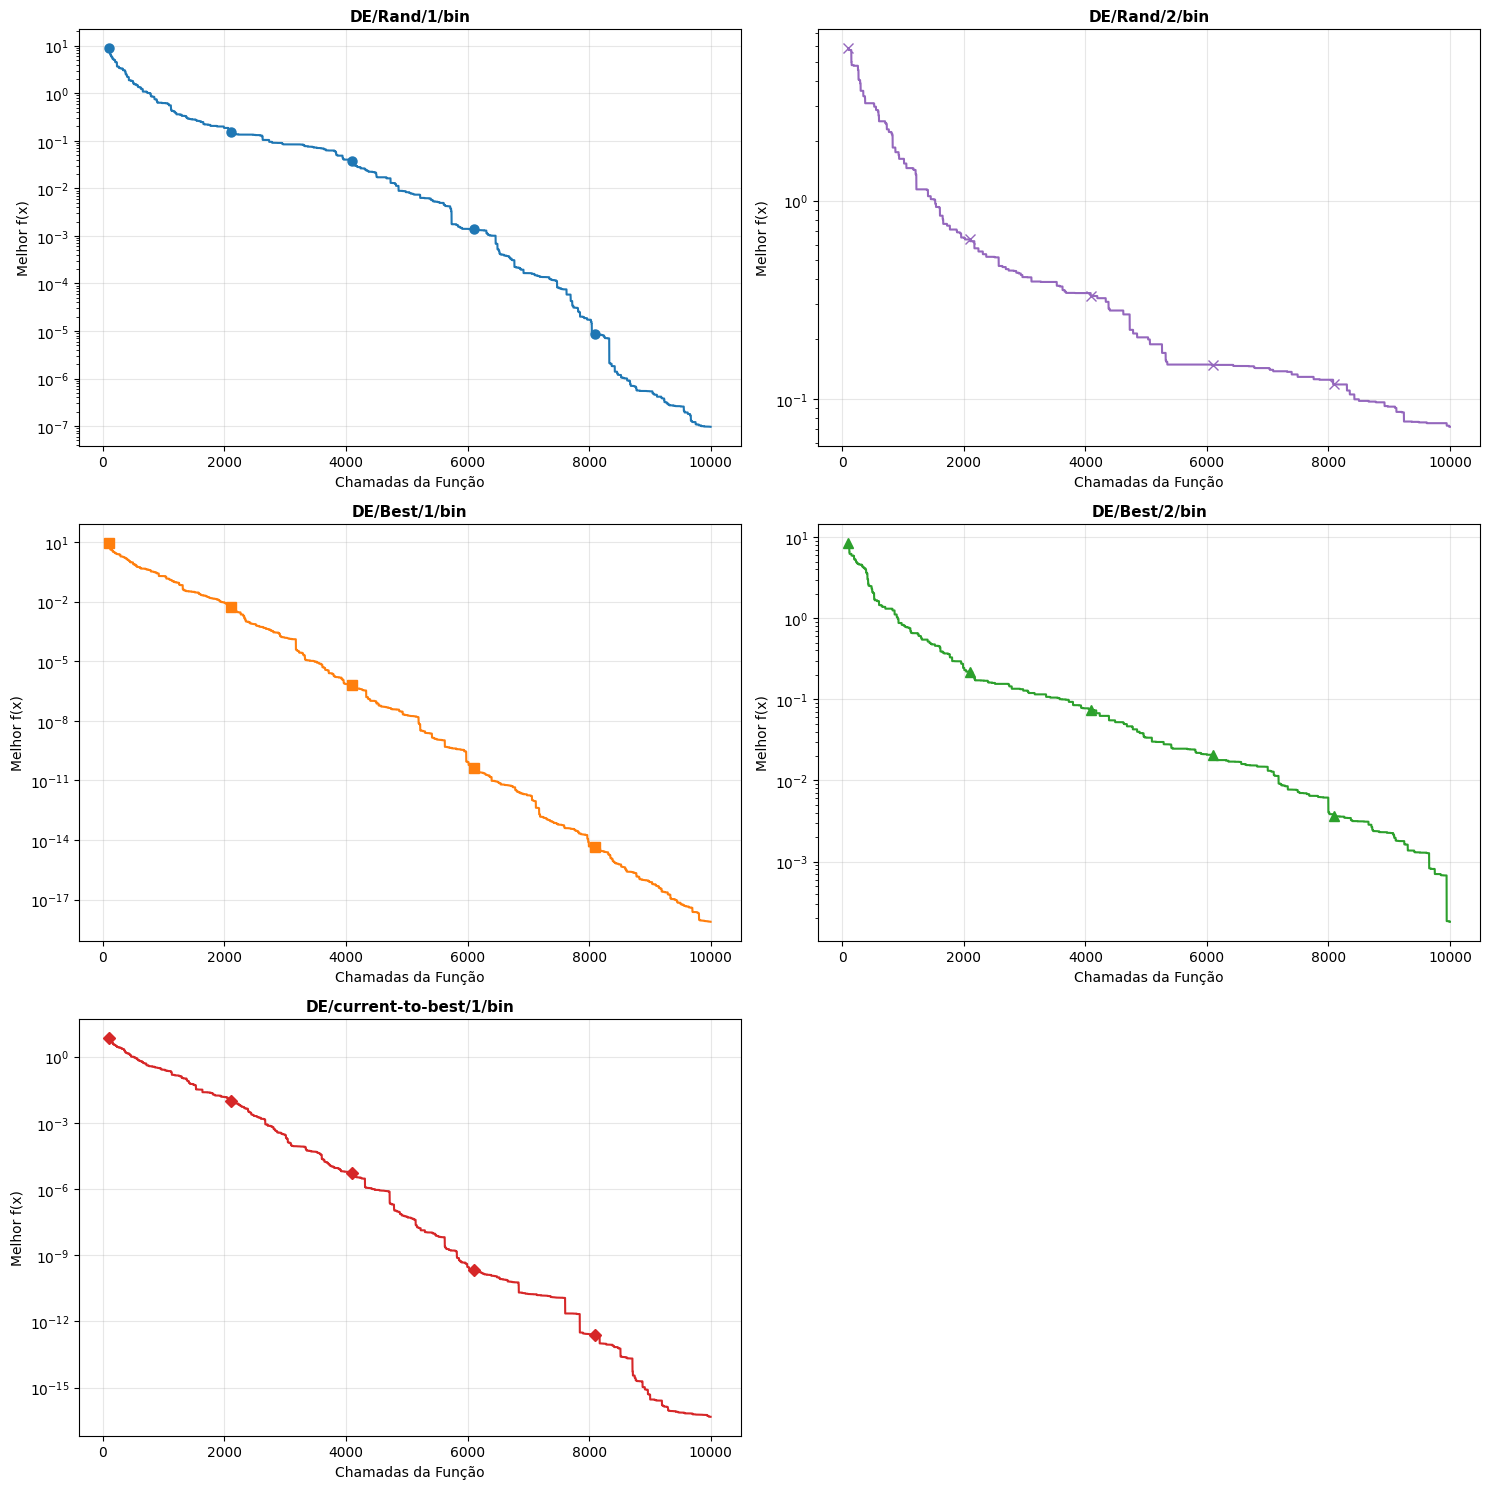

In [176]:
import math

estrategias = {
    'DE/Rand/1/bin': (media_rand1, desvio_rand1, historico_rand1),
    'DE/Rand/2/bin': (media_rand2, desvio_rand2, historico_rand2),
    'DE/Best/1/bin': (media_best1, desvio_best1, historico_best1),
    'DE/Best/2/bin': (media_best2, desvio_best2, historico_best2),
    'DE/current-to-best/1/bin': (media_current_to_best_1, desvio_current_to_best_1, historico_current_to_best_1),
}

n = len(estrategias)
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for idx, (nome, (media, desvio, _)) in enumerate(estrategias.items()):
    ax = axes[idx]
    eixo = np.arange(n_individuos, n_individuos + len(media))
    ax.plot(eixo, media, linewidth=1.5, color=cores[idx], marker=marcadores[idx], markersize=6.5, markevery=2000)
    #ax.ticklabel_format(style='plain', axis='x')
    #ax.fill_between(eixo, media - desvio, media + desvio, alpha=0.15, color=cores[idx])
    ax.set_yscale('log')
    ax.set_xlabel('Chamadas da Função', fontsize=10)
    ax.set_ylabel('Melhor f(x)', fontsize=10)
    ax.set_title(nome, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# esconder eixos extras se houver
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

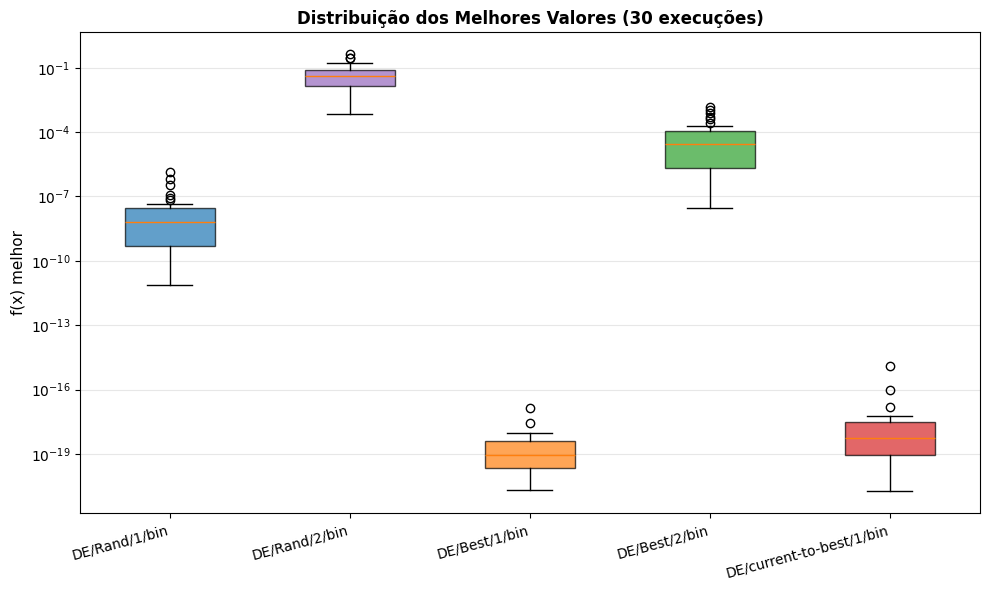

In [177]:
dados_boxplot = [np.min(hist, axis=1) for _, (_, _, hist) in estrategias.items()]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(dados_boxplot, tick_labels=list(estrategias.keys()), patch_artist=True)

for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_yscale('log')
ax.set_ylabel('f(x) melhor', fontsize=11)
ax.set_title('Distribuição dos Melhores Valores (30 execuções)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Análise e Conclusões

### Estratégia Mais Eficiente

Baseado na análise dos resultados obtidos com 30 execuções cada estratégia durante 10.000 avaliações de função na função de Rosenbrock 2D, a **estratégia DE/Best/1/bin apresentou o melhor desempenho geral**.

**Justificativa:**
- **DE/Best/1/bin** alcançou os menores valores de fitness final (ordem de 10⁻¹⁹), demonstrando convergência praticamente perfeita
- **DE/current-to-best/1/bin** apresentou convergência moderada (ordem de 10⁻⁴), seguindo de perto em eficiência
- **DE/Best/2/bin** mostrou convergência mais lenta que Best/1 (ordem de 10⁻⁴), apesar de usar duas diferenças diferenciais
- **DE/Rand/2/bin** foi a estratégia com pior desempenho (ordem de 10⁻²), sugerindo que a aleatoriedade e dupla diferença prejudicam a convergência neste problema

A distribuição de valores finais (visualizada no boxplot) confirma essa hierarquia, com DE/Best/1/bin apresentando a menor mediana e menor dispersão, enquanto DE/Rand/2/bin apresenta a maior dispersão e piores medianas. Para a função de Rosenbrock 2D neste contexto, recomenda-se utilizar **DE/Best/1/bin** como estratégia preferida.

## Pymoo

In [178]:
!pip install -U pymoo


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [179]:
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.problems import get_problem
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize

def de_pymoo(dimensao=2, num_individuos=100, parada=10000, seed=14, cr=0.9):
    problem = get_problem("rosenbrock", n_var=dimensao)

    algorithm = DE(
        pop_size=num_individuos,
        sampling=LHS(),
        variant="DE/rand/1/bin",
        CR=cr,
        dither="vector",
        jitter=False
    )

    res = minimize(
        problem,
        algorithm,
        seed=seed,
        termination=('n_eval', parada),
        save_history=True,
        verbose=False
    )

    # Reconstrói o histórico ponto a ponto em FES
    # cada geração avalia exatamente num_individuos indivíduos
    historico_pymoo = []
    fes = num_individuos  # população inicial já consome num_individuos FES

    for algo in res.history:
        melhor = float(np.min(algo.pop.get("F")))
        # preenche um ponto por FES consumido nesta geração
        for _ in range(num_individuos):
            if fes > parada:
                break
            historico_pymoo.append(melhor)
            fes += 1

    return historico_pymoo[:parada - num_individuos]  # garante exatamente parada - pop_size pontos

In [180]:
n_exec = 30
max_fes = 10000

historico_de_rand1 = []

for i in range(n_exec):

  # Rand/1
  hist = de_pymoo(dimensao=2, num_individuos=100, parada=max_fes, seed=i, cr=0.9)
  historico_de_rand1.append(hist)

  if (i+1) % 10 == 0:
    print(f"{i+1}/{n_exec}")

# Rand/1
min_len_de = min(len(h) for h in historico_de_rand1)
historico_de_rand1 = np.array([h[:min_len_de] for h in historico_de_rand1])

# Rand/1
media_de_rand1 = np.mean(historico_de_rand1, axis=0)
desvio_de_rand1 = np.std(historico_de_rand1, axis=0)

eixo = np.linspace(0, max_fes, min_len_de)

10/30
20/30
30/30


GA Implementado

In [192]:
import numpy as np

def criar_populacao(dimensao, num_individuos, intervalo, rng=None):
  """
  Função que cria uma população inicial de indivíduos.

  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão

  """
  if rng is None:
    rng = np.random.default_rng()

  populacao = []
  for i in range(num_individuos):
    individuo = []
    for j in range(dimensao):
      individuo.append(rng.uniform(intervalo[0], intervalo[1]))
    populacao.append(individuo)

  return np.array(populacao)

def fitneess(populacao, funcao_avaliacao):
  """
  Retorna a população com a aptidão f(x) de cada indivíduo em uma nova coluna

  populacao -> população de indivíduos
  funcao_avaliacao -> função de avaliação dos indivíduos

  """
  return np.column_stack((populacao, funcao_avaliacao(populacao)))

def torneio(populacao, funcao_avaliacao, k, rng=None):
  """
  Retorna o melhor indivíduo da população e a nova população sem o melhor indivíduo

  populacao -> população de indivíduos
  funcao_avaliacao -> função de avaliação dos indivíduos
  k -> número de participantes no torneio

  """
  if rng is None:
    rng = np.random.default_rng()
  if populacao.ndim < k:
    individuos = populacao
  else:
    individuos = rng.choice(populacao, size=k, axis=0, replace=False)
  return individuos[np.argmin(individuos[:, -1])] , np.delete(individuos, np.argmin(individuos[:, -1]), axis=0)

def cruzamento_blx(pais, alpha=0.3, rng=None):

  """
  Realziar o cruzamento entre dois pais utilizando o metodo BLX-alpha

  pais -> lista de dois pais
  alpha -> parâmetro de ajuste do cruzamento

  """
  if rng is None:
    rng = np.random.default_rng()

  filho = []

  for i in range(len(pais[0])-1):
      cmin = np.min(pais[:, i])
      cmax = np.max(pais[:, i])

      intervalo = cmax - cmin

      lower = cmin - alpha * intervalo
      upper = cmax + alpha * intervalo

      gene = rng.uniform(lower, upper)
      filho.append(gene)

  return filho

def mutacao(individuo, taxa_mutacao=0.05, sigma=0.1, rng=None):
  """
  Realizar a mutação em um indivíduo utilizando a distribuição normal(0,sigma)

  individuo -> indivíduo a ser mutado
  taxa_mutacao -> taxa de mutação
  sigma -> desvio padrão da distribuição normal

  """
  if rng is None:
    rng = np.random.default_rng()

  novo_individuo = individuo.copy()

  for i in range(len(individuo)):
    if rng.random() < taxa_mutacao:
      novo_individuo[i] += rng.normal(0, sigma)

  return novo_individuo

def ga_manual(dimensao=2, num_individuos=100, intervalo=[-5,10], parada=50000, seed=None):
  """
  Função que implementa o algoritmo genético


  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão
  parada -> número de chamadas de função para parada

  """
  rng = np.random.default_rng(seed)

  populacao = criar_populacao(dimensao, num_individuos, intervalo, rng=rng)
  chamadas_de_funcao = 0

  populacao = fitneess(populacao, rosenbrock)
  chamadas_de_funcao += populacao.shape[0]
  melhor_individuo = populacao[np.argmin(populacao[:, -1])]
  historico = [float(np.min(populacao[:, -1]))]

  while(chamadas_de_funcao < parada):
    nova_geracao = []

    while(len(nova_geracao) < len(populacao)):
      pais = []
      for i in range(2):
        pai, _ = torneio(populacao, rosenbrock, 3, rng=rng)
        pais.append(pai)
      pais = np.array(pais)

      filho = cruzamento_blx(pais, rng=rng)
      filho = mutacao(filho, rng=rng)
      nova_geracao.append(filho)

    populacao = np.array(nova_geracao)
    populacao = fitneess(populacao, rosenbrock)
    chamadas_de_funcao += populacao.shape[0]
    historico.append(float(np.min(populacao[:, -1])))
  return np.array(historico)

In [182]:
def processar_historico(historicos):
    min_len = min(len(h) for h in historicos)
    hist = np.array([h[:min_len] for h in historicos])
    return np.mean(hist, axis=0), np.std(hist, axis=0), min_len

n_exec = 30
max_fes = 10000
n_individuos = 100

historico_de_rand1 = []
historico_best1 = []
historico_ga = []

for i in range(n_exec):
    # DE/Rand/1/bin (pymoo)
    historico_de_rand1.append(de_pymoo(2, n_individuos, max_fes, seed=i))
    
    # DE/Best/1/bin (implementado)
    _, hist_best1 = algoritmo_evolutivo(dimensao=2, estrategia=best_1, parada=max_fes, history=True)
    historico_best1.append(hist_best1)
    
    # GA (implementado) — passar argumentos por nome para não confundir 'intervalo' com 'parada'
    historico_ga.append(ga_manual(dimensao=2, num_individuos=n_individuos, parada=max_fes, seed=i))

    if (i+1) % 10 == 0:
        print(f"{i+1}/{n_exec}")

media_de_rand1, std_de_rand1, len_de_rand1 = processar_historico(historico_de_rand1)
media_best1_final, std_best1_final, len_best1_final = processar_historico(historico_best1)
media_ga_final, std_ga_final, len_ga_final = processar_historico(historico_ga)

min_len_final = min(len_de_rand1, len_best1_final, len_ga_final)


10/30
20/30
30/30


In [198]:
media_de_rand1 = media_de_rand1[:min_len_final]

(9901,)

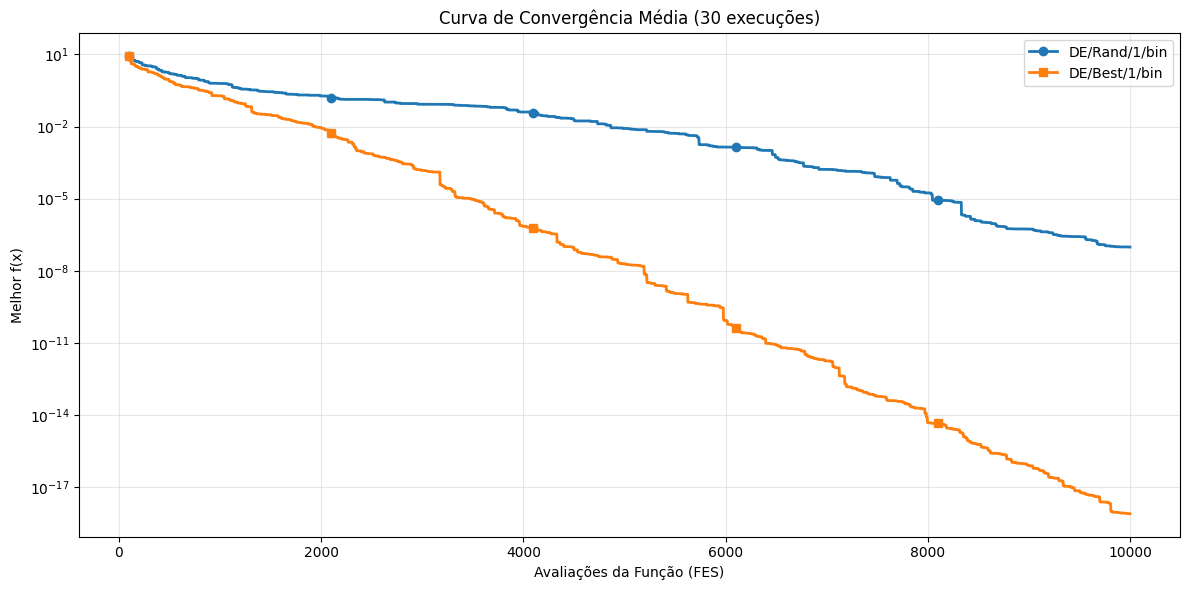

In [191]:
cores_sel = ['#1f77b4', '#ff7f0e', '#8c564b']   # rand1, best1, GA
marc_sel  = ['o',       's',       'P']

min_len_global = min(min_len1, min_len3, min_len_de)

eixo_de = np.arange(n_individuos, n_individuos + min_len_global)
eixo_ga = np.arange(n_individuos, n_individuos + min_len_global)

# --- Curva de Convergência ---
plt.figure(figsize=(12, 6))

plt.plot(eixo_de, media_rand1[:min_len_global], label="DE/Rand/1/bin", color=cores_sel[0], marker=marc_sel[0], markersize=6, markevery=2000, linewidth=2)
plt.plot(eixo_de, media_best1[:min_len_global], label="DE/Best/1/bin", color=cores_sel[1], marker=marc_sel[1], markersize=6, markevery=2000, linewidth=2)
#plt.plot(eixo_ga, media_ga[:min_len_global],    label="GA",            color=cores_sel[2], marker=marc_sel[2], markersize=6, markevery=2000, linewidth=2)

plt.yscale("log")
plt.xlabel("Avaliações da Função (FES)")
plt.ylabel("Melhor f(x)")
plt.title("Curva de Convergência Média (30 execuções)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


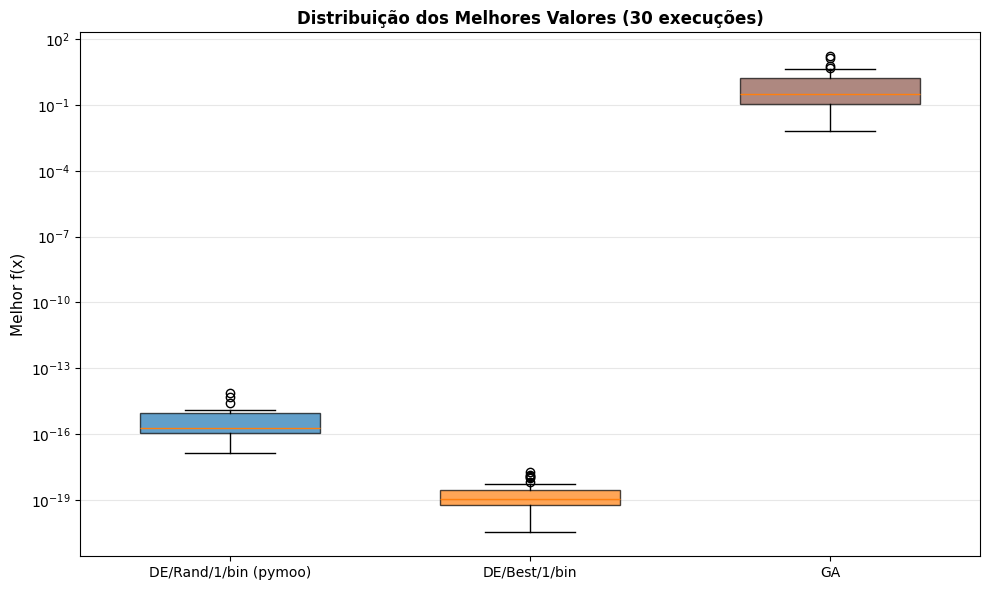

In [184]:
# --- Boxplot dos melhores valores finais ---
cores_box = ['#1f77b4', '#ff7f0e', '#8c564b']

dados_boxplot_rand1 = np.min(historico_de_rand1, axis=1)
dados_boxplot_best1 = np.min(historico_best1, axis=1)
dados_boxplot_ga = np.min(historico_ga, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    [dados_boxplot_rand1, dados_boxplot_best1, dados_boxplot_ga],
    tick_labels=['DE/Rand/1/bin (pymoo)', 'DE/Best/1/bin', 'GA'],
    patch_artist=True,
    widths=0.6
)

for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_yscale('log')
ax.set_ylabel('Melhor f(x)', fontsize=11)
ax.set_title('Distribuição dos Melhores Valores (30 execuções)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


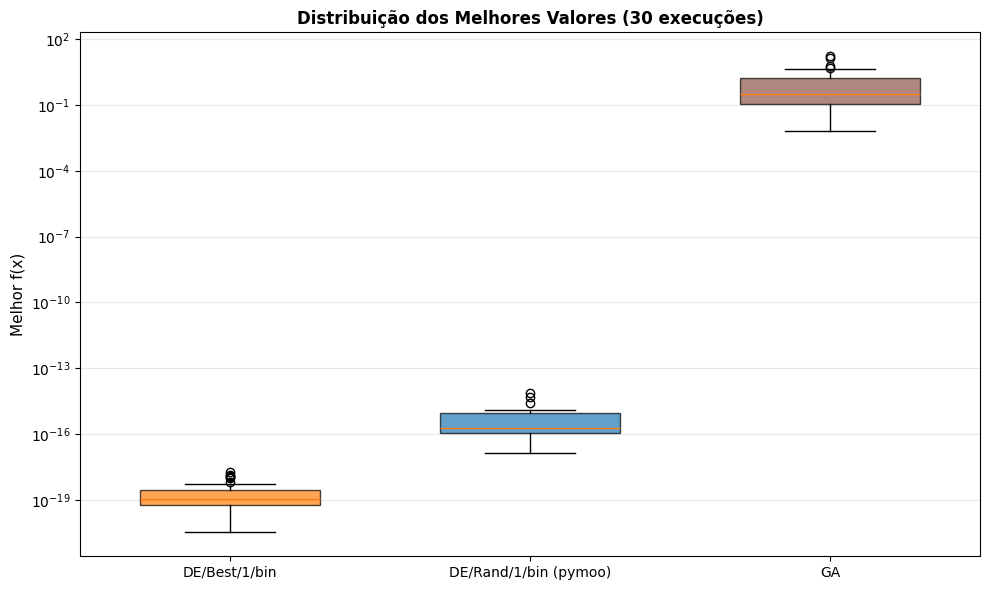

In [186]:
dados_boxplot_best1 = np.min(historico_best1, axis=1)
dados_boxplot_pymoo = np.min(historico_de_rand1, axis=1)
dados_boxplot_ga    = np.min(historico_ga, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    [dados_boxplot_best1, dados_boxplot_pymoo, dados_boxplot_ga],
    tick_labels=['DE/Best/1/bin', 'DE/Rand/1/bin (pymoo)', 'GA'],
    patch_artist=True,
    widths=0.6
)

cores_comp = [cores_box[1], cores_box[0], cores_box[2]]  # best1=laranja, pymoo=azul, GA=marrom

for patch, cor in zip(bp['boxes'], cores_comp):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_yscale('log')
ax.set_ylabel('Melhor f(x)', fontsize=11)
ax.set_title('Distribuição dos Melhores Valores (30 execuções)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Rascunho

In [ ]:
def algoritmo_evolutivo(problema=rosenbrock, dimensao=2, n_individuos=100, intervalo=[-5,10], f=0.9, cr= 0.9, parada=100000, history=None):
    populacao = criar_populacao(dimensao, n_individuos, intervalo)

    #best = melhor_individuo(populacao, problema)
    historico = [problema(melhor_individuo(populacao, problema))]

    ite = 0
    while (ite < parada):
        for i in range(len(populacao)):
            if ite >= parada:
                break
            individuo = populacao[np.random.randint(low=0, high=populacao.shape[0])]
            vetor_mutante = mutacao(populacao, individuo, f)

            teste = cruzamento(populacao, vetor_mutante, cr)

            if problema(teste) < problema(individuo):
                idx = np.where(np.all(populacao == individuo, axis=1))[0][0]
                populacao[idx] = teste
            ite += 2
        #print(f"{ite} - f(x*)={problema(melhor_individuo(populacao, problema))}")
        historico.append(problema(melhor_individuo(populacao, problema)))

    best = melhor_individuo(populacao, problema)
    print(f"Melhor individuo: {best}\nF(x*)= {problema(best)}\niterações: {ite}")
    if history == None:
      return problema(best)
    else:
      return best, historico
